# TPP Evaluating

Evaluate compensator behavior of a trained TPP model on the full catalog sequence.

## 1) Setup

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog
from src.utils.utils import set_seed

set_seed(0)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Load Trained Model

In [6]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'rtpp_20250907-144043'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'last_model_1.pth'
USE_TORCH_COMPILE = True


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Model: {args.model} | Dataset: {args.dataset}')

Loaded checkpoint: /root/autodl-tmp/em_eqf/checkpoints/rtpp_20250907-144043/last_model_1.pth
Model: rtpp | Dataset: ChuanDian


## 3) Load Catalog and Evaluate Compensator

In [ ]:
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=getattr(args, 'catalog_cfg', {}),
)
print(f'Using catalog registry name: {registry_name}')

seq = catalog_ds.full_sequence.to(DEVICE)
grid, compensator = model.evaluate_compensator(seq)

grid_np = grid.detach().cpu().numpy()
comp_np = compensator.detach().cpu().numpy()
arrival_times_np = seq.arrival_times.detach().cpu().numpy()

print(f'Full sequence events: {len(arrival_times_np)}')
print(f'Grid shape: {grid_np.shape} | Compensator shape: {comp_np.shape}')

Full sequence events: 11580
Grid shape: (579050,) | Compensator shape: (579050,)


## 4) Visualization

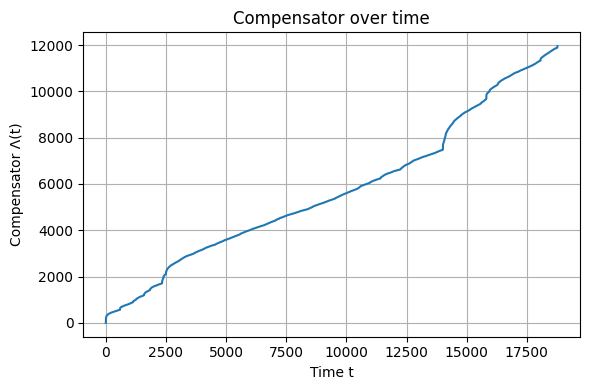

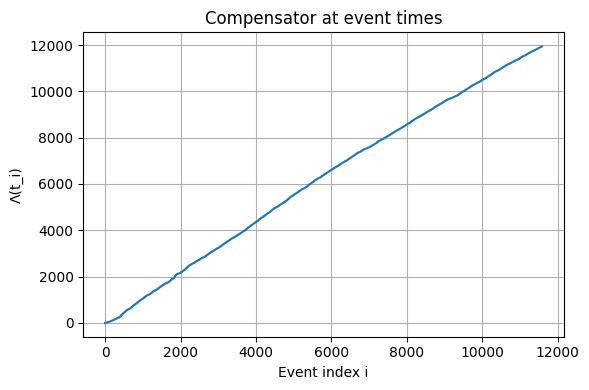

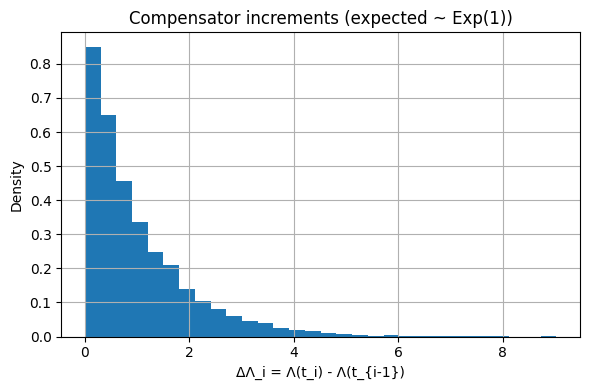

In [12]:
def compensator_at_event_times(grid_values: np.ndarray, comp_values: np.ndarray, event_times: np.ndarray) -> np.ndarray:
    # side='right'-1 gives the last grid point <= event time.
    idx = np.searchsorted(grid_values, event_times, side='right') - 1
    idx = np.clip(idx, 0, len(comp_values) - 1)
    return comp_values[idx]


event_comp = compensator_at_event_times(grid_np, comp_np, arrival_times_np)
increments = np.diff(event_comp)

plt.figure(figsize=(6, 4))
plt.plot(grid_np, comp_np)
plt.xlabel('Time t')
plt.ylabel('Compensator Λ(t)')
plt.title('Compensator over time')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.step(range(1, len(event_comp) + 1), event_comp, where='post')
plt.xlabel('Event index i')
plt.ylabel('Λ(t_i)')
plt.title('Compensator at event times')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(increments, bins=30, density=True)
plt.xlabel('ΔΛ_i = Λ(t_i) - Λ(t_{i-1})')
plt.ylabel('Density')
plt.title('Compensator increments (expected ~ Exp(1))')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
print('Increment summary:')
print(f'count={len(increments)}')
print(f'mean={increments.mean():.4f}')
print(f'std={increments.std():.4f}')
print(f'min={increments.min():.4f}')
print(f'max={increments.max():.4f}')

Increment summary:
count=11579
mean=1.0318
std=1.0407
min=0.0000
max=9.0240
